In [1]:
#pip install Pillow numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import rasterio
from PIL import Image

def extract_and_resize_rgb(image_path, resize_size=(224, 224)):
    with rasterio.open(image_path) as src:
        # Read RGB bands (assumes the first three bands are RGB)
        img_array = src.read([1, 2, 3])  # Read first, second, third bands
        img_array = np.transpose(img_array, (1, 2, 0))  # Change to (height, width, bands)
    
    # Convert to PIL Image for resizing
    img_pil = Image.fromarray(img_array)
    
    # Resize image
    img_resized = img_pil.resize(resize_size, Image.ANTIALIAS)

    return img_resized

def process_all_geotiffs(input_directory, output_directory, csv_file_path):
    # Prepare list to record file paths
    records = []

    # Make sure output directory exists
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Iterate through each GeoTIFF file in the specified directory
    for filename in os.listdir(input_directory):
        if filename.lower().endswith('.tif') or filename.lower().endswith('.tiff'):
            image_path = os.path.join(input_directory, filename)
            print(f'Processing: {filename}')

            # Extract and resize RGB band
            img_resized = extract_and_resize_rgb(image_path)
            
            # Construct output file path
            output_file_path = os.path.join(output_directory, filename)

            # Save resized image as TIFF
            img_resized.save(output_file_path, format='TIFF')

            # Record the file paths in the list
            records.append({"original_path": image_path, "resized_path": output_file_path})

    # Save the records to a CSV file
    df = pd.DataFrame(records)
    df.to_csv(csv_file_path, index=False)

# Example usage
input_directory = '/home/xxzhang/Indonesia_MiningMap/Imagery/'  # Replace with your input directory path
output_directory = '/home/xxzhang/Indonesia_MiningMap/ResizedImagery/'  # Replace with your output directory path
csv_file_path = '/home/xxzhang/Indonesia_MiningMap/ResizedImagery/output_file_paths.csv'  # Path to save the CSV file

process_all_geotiffs(input_directory, output_directory, csv_file_path)

print("Processing complete. File paths saved to:", csv_file_path)

Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_15.tif


TypeError: Cannot handle this data type: (1, 1, 3), <i4

In [4]:
import os
import numpy as np
import pandas as pd
import rasterio
from PIL import Image
import shutil  # Used to delete existing directories

def stretch_to_255(img_band):
    """Linearly stretch the band values to the range of 0-255."""
    min_val = np.min(img_band)
    max_val = np.max(img_band)

    # Avoid division by zero
    if max_val - min_val == 0:
        return np.zeros_like(img_band, dtype=np.uint8)

    # Linearly scale to 0-255
    stretched = (img_band - min_val) / (max_val - min_val) * 255
    return stretched.astype(np.uint8)

def extract_and_resize_rgb(image_path, resize_size=(224, 224)):
    with rasterio.open(image_path) as src:
        # Read the RGB bands (assuming the first three bands are RGB)
        img_array = src.read([1, 2, 3])  # Read the first, second, and third bands
        img_array = np.transpose(img_array, (1, 2, 0))  # Change to (height, width, bands)

    # Stretch each band to the range of 0-255
    rgb_stretched = np.zeros_like(img_array, dtype=np.uint8)
    for i in range(3):  # Assuming the first three bands are R, G, B
        rgb_stretched[:, :, i] = stretch_to_255(img_array[:, :, i])

    # Convert to PIL Image and resize
    img_pil = Image.fromarray(rgb_stretched)
    img_resized = img_pil.resize(resize_size, Image.LANCZOS)

    return img_resized

def process_all_geotiffs(input_directory, output_directory, csv_file_path):
    # If the output directory exists, delete it
    if os.path.exists(output_directory):
        shutil.rmtree(output_directory)
    os.makedirs(output_directory)  # Create the output directory

    # Prepare a list to record file paths
    records = []

    # Iterate through each GeoTIFF file in the specified directory
    for filename in os.listdir(input_directory):
        if filename.lower().endswith(('.tif', '.tiff')):  # Check file extension
            image_path = os.path.join(input_directory, filename)
            print(f'Processing: {filename}')

            try:
                # Extract and resize RGB bands
                img_resized = extract_and_resize_rgb(image_path)
                
                # Construct the output file path
                output_file_path = os.path.join(output_directory, filename)

                # Save the resized image as TIFF
                img_resized.save(output_file_path, format='TIFF')

                # Record the file paths in the list
                records.append({
                    "original_path": image_path,
                    "resized_path": output_file_path
                })
            except Exception as e:
                print(f"Error processing {filename}: {e}")

    # Save the records to a CSV file (it will be overwritten if it exists)
    df = pd.DataFrame(records)
    df.to_csv(csv_file_path, index=False)

# Example usage
input_directory = '/home/xxzhang/Indonesia_MiningMap/Imagery/'  # Replace with your input directory path
output_directory = '/home/xxzhang/Indonesia_MiningMap/ResizedImagery/'  # Replace with your output directory path
csv_file_path = '/mnt/DiskA/xxzhang/Indnoesia/Indonesia_MiningMap/Resized_Images_Paths.csv'  # Path to save CSV file

process_all_geotiffs(input_directory, output_directory, csv_file_path)

print("Processing complete. File paths saved to:", csv_file_path)

Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_15.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_39.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_48.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_28.tif


/tmp/ipykernel_56398/125868054.py:34: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img_resized = img_pil.resize(resize_size, Image.LANCZOS)


Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_46.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_27.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_44.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_4.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_30.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_43.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_12.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_23.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_10.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_13.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_31.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_37.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_40.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_1.tif
Processing: Planet2024_Indonesia_Jan_Jul_Median_TrainingAOI_0.ti

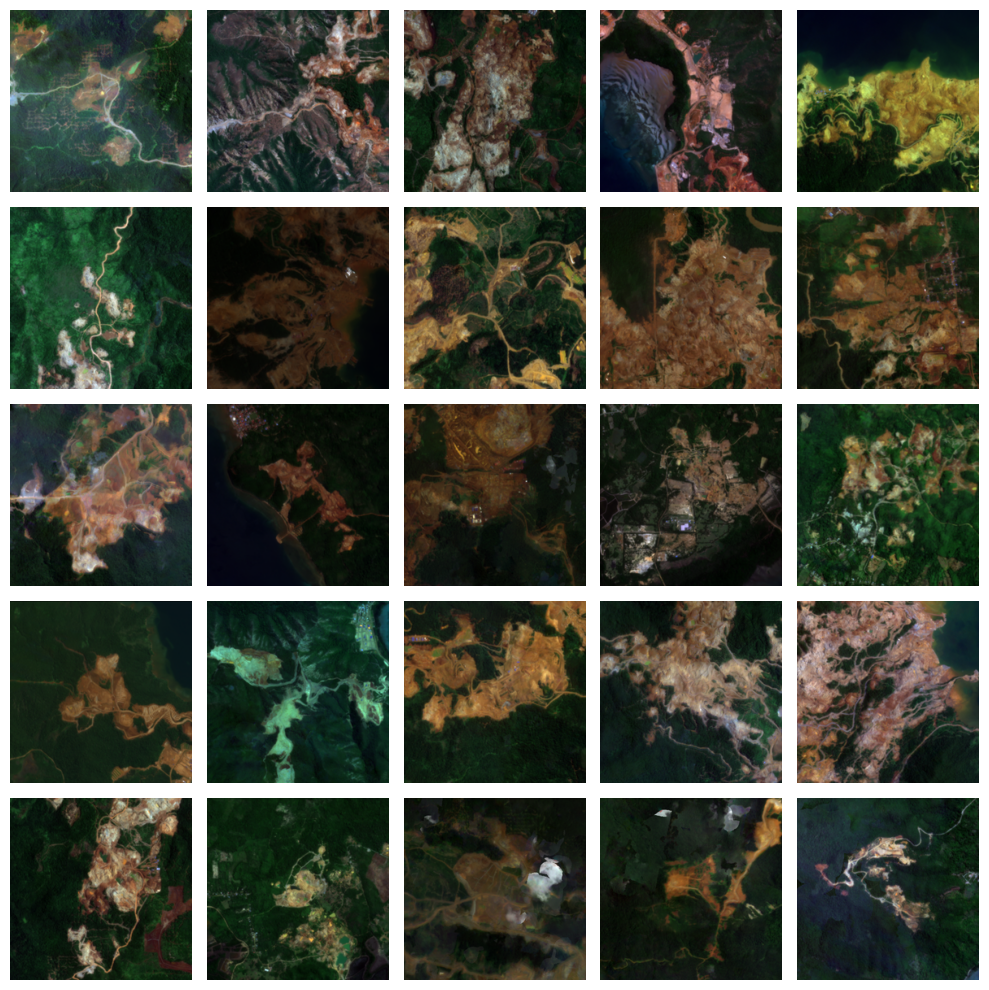

In [8]:
import shutil
import random
import matplotlib.pyplot as plt

def display_random_images(output_directory, num_images=25, grid_shape=(5, 5)):
    # Get all saved images in the output directory
    all_images = [f for f in os.listdir(output_directory) if f.lower().endswith(('.tif', '.tiff'))]
    
    # Randomly select images
    selected_images = random.sample(all_images, num_images)
    
    # Create a grid for displaying images
    fig, axes = plt.subplots(grid_shape[0], grid_shape[1], figsize=(10, 10))
    for ax, img_name in zip(axes.flatten(), selected_images):
        img_path = os.path.join(output_directory, img_name)
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')  # Hide axis

    # Show the plot
    plt.tight_layout()
    plt.show()

# Example usage
input_directory = '/home/xxzhang/Indonesia_MiningMap/Imagery/'  # Replace with your input directory path
output_directory = '/home/xxzhang/Indonesia_MiningMap/ResizedImagery/'  # Replace with your output directory path
csv_file_path = '/home/xxzhang/Indonesia_MiningMap/ResizedImagery/output_file_paths.csv'  # Path to save CSV file

# Now display 16 random images from the output directory
display_random_images(output_directory)